# 1. Email Spam Detection using TF-IDF + Logistic Regression
# Task: Classify emails as spam or ham using TF-IDF and logistic regression.

In [2]:
emails = [
    ("Win a FREE trip now!", "spam"),
    ("Please review the attached report", "ham"),
    ("Congratulations, you have won a lottery!", "spam"),
    ("Meeting scheduled at 10 AM tomorrow", "ham"),
    ("Free coupons waiting for you", "spam")
]


# solution

In [2]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
import pandas as pd

# 1. Dataset
emails = [
    ("Win a FREE trip now!", "spam"),
    ("Please review the attached report", "ham"),
    ("Congratulations, you have won a lottery!", "spam"),
    ("Meeting scheduled at 10 AM tomorrow", "ham"),
    ("Free coupons waiting for you", "spam")
]

# Separate data into texts (X) and labels (y)
data = pd.DataFrame(emails, columns=['text', 'label'])
X = data['text']
y = data['label']

# 2. Convert text to numerical data using TF-IDF
# TfidfVectorizer ignores punctuation and lowercase by default
vectorizer = TfidfVectorizer(stop_words='english')
X_tfidf = vectorizer.fit_transform(X)

# 3. Train the Logistic Regression Model
clf = LogisticRegression()
clf.fit(X_tfidf, y)

# 4. Predict on the same data to see how it classified them
predictions = clf.predict(X_tfidf)

# Display Results
for email, label in zip(X, predictions):
    print(f"[{label.upper()}] - {email}")

# --- Optional: Test with new unseen emails ---
new_emails = ["Get free money now", "Project update meeting"]
new_tfidf = vectorizer.transform(new_emails)
new_predictions = clf.predict(new_tfidf)
print("\nNew Predictions:")
for email, label in zip(new_emails, new_predictions):
    print(f"[{label.upper()}] - {email}")


[SPAM] - Win a FREE trip now!
[HAM] - Please review the attached report
[SPAM] - Congratulations, you have won a lottery!
[HAM] - Meeting scheduled at 10 AM tomorrow
[SPAM] - Free coupons waiting for you

New Predictions:
[SPAM] - Get free money now
[SPAM] - Project update meeting


# 2. News Classification using CountVectorizer
# Task: Classify news into politics or sports.

In [8]:
news_data = [
    ("The prime minister addressed the nation.", "politics"),
    ("The team won the cricket match yesterday.", "sports"),
    ("New laws were introduced in the parliament.", "politics"),
    ("Football tournament starts next week.", "sports"),
    ("Government announces new tax reforms.", "politics"),
    ("The opposition leader criticized the budget plan.", "politics"),
    ("India defeated Australia in the final match.", "sports"),
    ("The president signed the healthcare bill.", "politics"),
    ("Tennis champion wins her sixth Grand Slam title.", "sports"),
    ("Cabinet approves new education policy.", "politics"),
    ("The hockey league season begins tomorrow.", "sports"),
    ("Parliament passes the environmental protection act.", "politics"),
    ("The coach announced the final team squad.", "sports"),
    ("Elections to be held in five states next month.", "politics"),
    ("Star player scores a hat-trick in the football match.", "sports"),
    ("Supreme Court hears plea on a on recent ordinance.", "politics")]


# solution

In [4]:
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import classification_report, accuracy_score

# 1. Dataset setup
news_data = [
    ("The prime minister addressed the nation.", "politics"),
    ("The team won the cricket match yesterday.", "sports"),
    ("New laws were introduced in the parliament.", "politics"),
    ("Football tournament starts next week.", "sports"),
    ("Government announces new tax reforms.", "politics"),
    ("The opposition leader criticized the budget plan.", "politics"),
    ("India defeated Australia in the final match.", "sports"),
    ("The president signed the healthcare bill.", "politics"),
    ("Tennis champion wins her sixth Grand Slam title.", "sports"),
    ("Cabinet approves new education policy.", "politics"),
    ("The hockey league season begins tomorrow.", "sports"),
    ("Parliament passes the environmental protection act.", "politics"),
    ("The coach announced the final team squad.", "sports"),
    ("Elections to be held in five states next month.", "politics"),
    ("Star player scores a hat-trick in the football match.", "sports"),
    ("Supreme Court hears plea on a on recent ordinance.", "politics")
]

# Separate features (text) and target labels
X, y = zip(*news_data)

# 2. Vectorize the text data using CountVectorizer
vectorizer = CountVectorizer(stop_words='english')
X_vectorized = vectorizer.fit_transform(X)

# 3. Train a Multinomial Naive Bayes Classifier
# Using a small split for demonstration; in production use larger datasets
X_train, X_test, y_train, y_test = train_test_split(X_vectorized, y, test_size=0.2, random_state=42)

model = MultinomialNB()
model.fit(X_train, y_train)

# 4. Evaluate the model
y_pred = model.predict(X_test)
print(f"Accuracy: {accuracy_score(y_test, y_pred) * 100}%")

# 5. Predict on new incoming headlines
new_headlines = [
    "The prime minister is planning a new budget meeting next Tuesday.",
    "The football team won the championship cup easily."
]

new_X = vectorizer.transform(new_headlines)
predictions = model.predict(new_X)

for headline, category in zip(new_headlines, predictions):
    print(f"Headline: '{headline}' -> Classified as: **{category}**")

Accuracy: 100.0%
Headline: 'The prime minister is planning a new budget meeting next Tuesday.' -> Classified as: **politics**
Headline: 'The football team won the championship cup easily.' -> Classified as: **sports**


# 3. Product Review Sentiment using VADER
# Task: Perform sentiment analysis on product reviews.

In [10]:
reviews = [
    "Absolutely love this product, it works like a charm!",
    "Worst experience ever. Will never buy again.",
    "It's okay, not great but not bad either.",
    "Very satisfied with the quality!",
    "Disappointed. It stopped working in a week."
]


# solution

In [7]:
# from nltk.sentiment.vader import SentimentIntensityAnalyzer

reviews = [
    "Absolutely love this product, it works like a charm!",
    "Worst experience ever. Will never buy again.",
    "It's okay, not great but not bad either.",
    "Very satisfied with the quality!",
    "Disappointed. It stopped working in a week."
]

# Initialize VADER
analyzer = SentimentIntensityAnalyzer()

# Analyze reviews
for review in reviews:
    score = analyzer.polarity_scores(review)
    compound = score['compound']
    
    # Classify sentiment
    if compound >= 0.05:
        sentiment = "Positive"
    elif compound <= -0.05:
        sentiment = "Negative"
    else:
        sentiment = "Neutral"
        
    print(f"Review: \"{review}\"\nScore: {compound} ({sentiment})\n")

Review: "Absolutely love this product, it works like a charm!"
Score: 0.8746 (Positive)

Review: "Worst experience ever. Will never buy again."
Score: -0.6249 (Negative)

Review: "It's okay, not great but not bad either."
Score: 0.4728 (Positive)

Review: "Very satisfied with the quality!"
Score: 0.5244 (Positive)

Review: "Disappointed. It stopped working in a week."
Score: -0.6124 (Negative)



# 4. Topic Modeling on Articles using LDA
# Task: Extract 2 topics from a list of article contents.

In [12]:
docs = [
    "Deep learning models can process images and videos.",
    "Neural networks are at the core of deep learning.",
    "Global warming affects the climate and ecosystems.",
    "Carbon emissions cause climate change.",
    "Convolutional neural networks perform well in vision tasks."
]


# solution

In [8]:
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation

docs = [
    "Deep learning models can process images and videos.",
    "Neural networks are at the core of deep learning.",
    "Global warming affects the climate and ecosystems.",
    "Carbon emissions cause climate change.",
    "Convolutional neural networks perform well in vision tasks."
]

# 1. Vectorize text (remove English stop words)
vectorizer = CountVectorizer(stop_words='english')
doc_term_matrix = vectorizer.fit_transform(docs)

# Get feature names (words)
feature_names = vectorizer.get_feature_names_out()

# 2. Apply LDA
# n_components is the number of topics
lda_model = LatentDirichletAllocation(n_components=2, random_state=42)
lda_model.fit(doc_term_matrix)

# Display topics
words = vectorizer.get_feature_names_out()
for idx, topic in enumerate(lda_model.components_):
    print(f"Topic #{idx + 1}:")
    print([words[i] for i in topic.argsort()[-5:]])

Topic #1:
['tasks', 'convolutional', 'vision', 'networks', 'neural']
Topic #2:
['process', 'videos', 'climate', 'learning', 'deep']


#  5. Word Cloud for Movie Reviews
# Task: Visualize frequently used words in movie reviews.

In [14]:
movie_reviews = """
The movie was fantastic! Acting was brilliant and the story was well-written.
Amazing visuals and a gripping plot.
It was a bit slow in the middle, but overall a great movie experience.
"""


# solution

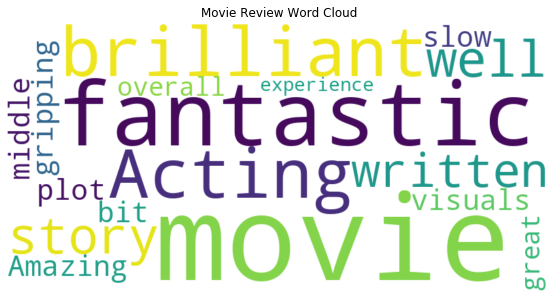

In [10]:
import matplotlib.pyplot as plt
from wordcloud import WordCloud

# Input text
movie_reviews = """
The movie was fantastic! Acting was brilliant and the story was well-written.
Amazing visuals and a gripping plot.
It was a bit slow in the middle, but overall a great movie experience.
"""

# Create the word cloud object
# You can find documentation on customization at the [WordCloud GitHub](https://github.com)
wordcloud = WordCloud(width=800, height=400, background_color='white').generate(movie_reviews)

# Plot the word cloud using [Matplotlib](https://matplotlib.org)
plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.title("Movie Review Word Cloud")
plt.axis('off')  # Remove axes
plt.show()
